<div style="text-align: center; font-size: 40px; font-weight: bold;">
    Train Model Deeplabv3+ Architecture
</div>

# Libraries

In [1]:
import tensorflow as tf
import numpy as np
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import os
import cv2
from PIL import Image
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras import backend as K

# Load Data

In [2]:
IMG_SIZE = (512, 512)

def load_image(img_path, mask_path):
    # ----- image -----
    img = tf.io.read_file(img_path)
    img = tf.image.decode_bmp(img, channels=3)   # gambar input RGB
    img = tf.image.resize(img, (IMG_SIZE[0], IMG_SIZE[1]))
    img = tf.cast(img, tf.float32) / 255.0

    # ----- mask -----
    mask = tf.io.read_file(mask_path)
    mask = tf.image.decode_bmp(mask, channels=0)   # biarkan sesuai file
    mask = tf.image.resize(mask, (IMG_SIZE[0], IMG_SIZE[1]), method="nearest")
    
    # pastikan hanya 1 channel
    if tf.shape(mask)[-1] != 1:
        mask = tf.image.rgb_to_grayscale(mask)

    # ubah ke {0,1}
    mask = tf.cast(mask > 127, tf.float32)

    return img, mask

def make_dataset(img_dir, mask_dir, batch_size=4, shuffle=True):
    img_files = sorted([os.path.join(img_dir, f) for f in os.listdir(img_dir)])
    mask_files = sorted([os.path.join(mask_dir, f) for f in os.listdir(mask_dir)])
    ds = tf.data.Dataset.from_tensor_slices((img_files, mask_files))
    ds = ds.map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
    if shuffle:
        ds = ds.shuffle(buffer_size=100)
    ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return ds

train_ds = make_dataset("Data_split/train/images", "Data_split/train/masks", batch_size=4)
val_ds   = make_dataset("Data_split/valid/images", "Data_split/valid/masks", batch_size=4, shuffle=False)

In [3]:
def dice_loss(y_true, y_pred, smooth: float = 1e-6) -> tf.Tensor:
    """
    Computes the Dice loss for image segmentation.
    
    Args:
        y_true: Ground truth binary mask.
        y_pred: Predicted mask.
        smooth (float): Smoothing factor to avoid division by zero.
    
    Returns:
        tf.Tensor: Dice loss value.
    """
    y_true = tf.cast(y_true, tf.float32)
    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)
    intersection = K.sum(y_true_f * y_pred_f)
    
    return 1 - ((2. * intersection + smooth) / (K.sum(y_true_f) + K.sum(y_pred_f) + smooth))

In [4]:
def iou_metric(y_true, y_pred, thr=0.5, smooth=1.0):
    y_pred_bin = tf.cast(y_pred > thr, tf.float32)
    inter = tf.reduce_sum(y_true * y_pred_bin, axis=[1,2,3])
    union = tf.reduce_sum(y_true, axis=[1,2,3]) + tf.reduce_sum(y_pred_bin, axis=[1,2,3]) - inter
    return tf.reduce_mean((inter + smooth) / (union + smooth))

In [5]:
def segnet(input_shape=(512, 512, 3)):  # ← 3 channel
    inp = layers.Input(shape=input_shape)

    # Encoder
    x = layers.Conv2D(64, 3, padding='same', activation='relu')(inp)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(64, 3, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    p1 = layers.MaxPooling2D(2)(x)

    x = layers.Conv2D(128, 3, padding='same', activation='relu')(p1)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(128, 3, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    p2 = layers.MaxPooling2D(2)(x)

    x = layers.Conv2D(256, 3, padding='same', activation='relu')(p2)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(256, 3, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    p3 = layers.MaxPooling2D(2)(x)

    x = layers.Conv2D(512, 3, padding='same', activation='relu')(p3)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.3)(x)

    # Decoder
    x = layers.Conv2DTranspose(256, 3, strides=2, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(256, 3, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)

    x = layers.Conv2DTranspose(128, 3, strides=2, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(128, 3, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)

    x = layers.Conv2DTranspose(64, 3, strides=2, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(64, 3, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)

    out = layers.Conv2D(1, 1, activation='sigmoid')(x)  # mask tetap 1 channel
    return models.Model(inp, out, name="SegNetBinary512_RGB")

model = segnet(input_shape=(512, 512, 3))


In [6]:
# Kompilasi model
# ======= Kompilasi Model =======
model.compile(optimizer='adam',
              loss=dice_loss,
              metrics=['accuracy', iou_metric])

# ======= Callbacks =======
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

lr_reduce = ReduceLROnPlateau(monitor='val_loss', 
                              factor=0.5, 
                              patience=5, 
                              min_lr=1e-6,
                              verbose=1)

model_checkpoint = ModelCheckpoint('Model/model_segnet.h5', 
                                   monitor='val_loss', 
                                   save_best_only=True, 
                                   verbose=1)

callbacks = [early_stop, lr_reduce, model_checkpoint]
# ======= Training Contoh =======
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=100,
    callbacks=callbacks
)

Epoch 1/100
149/149 [==============================] - ETA: 0s - loss: 0.3367 - accuracy: 0.9267 - iou_metric: 0.5297
Epoch 1: val_loss improved from inf to 0.99988, saving model to Model\model_segnet.h5
149/149 [==============================] - 103s 511ms/step - loss: 0.3367 - accuracy: 0.9267 - iou_metric: 0.5297 - val_loss: 0.9999 - val_accuracy: 0.9100 - val_iou_metric: 4.3896e-05 - lr: 0.0010
Epoch 2/100
149/149 [==============================] - ETA: 0s - loss: 0.2116 - accuracy: 0.9628 - iou_metric: 0.6558
Epoch 2: val_loss did not improve from 0.99988
149/149 [==============================] - 60s 397ms/step - loss: 0.2116 - accuracy: 0.9628 - iou_metric: 0.6558 - val_loss: 0.9999 - val_accuracy: 0.9100 - val_iou_metric: 4.3896e-05 - lr: 0.0010
Epoch 3/100
149/149 [==============================] - ETA: 0s - loss: 0.1882 - accuracy: 0.9669 - iou_metric: 0.6854
Epoch 3: val_loss did not improve from 0.99988
149/149 [==============================] - 60s 397ms/step - loss: 0.188

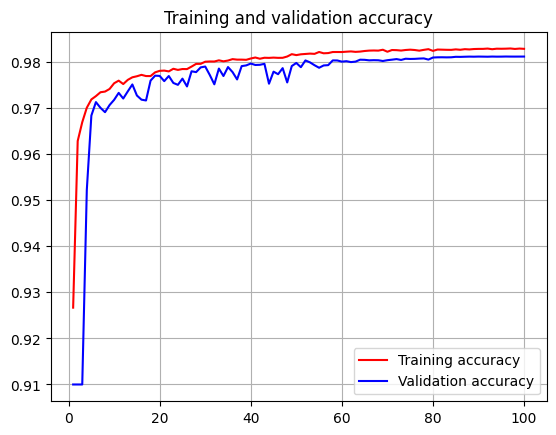

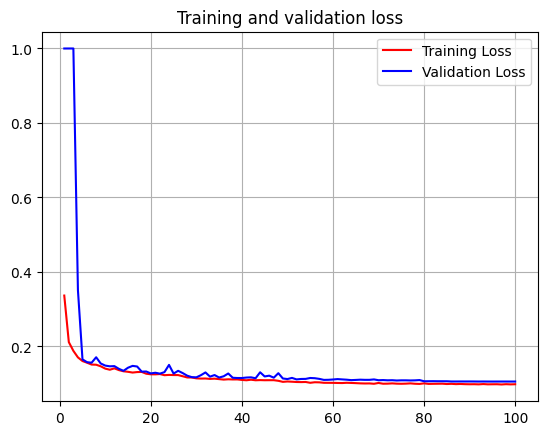

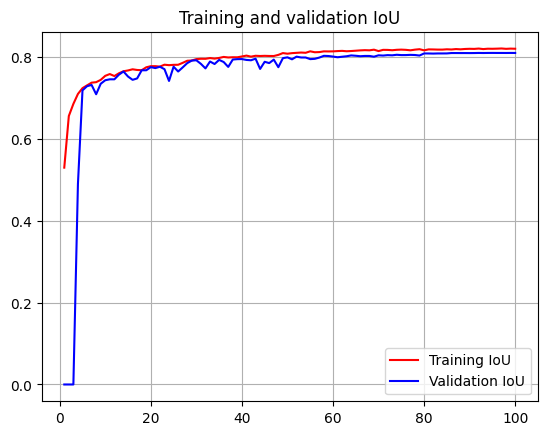

In [7]:
# Extract data from history.history
epochs = range(1, len(history.history['loss']) + 1)
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
iou = history.history['iou_metric']
val_iou = history.history['val_iou_metric']

# Plotting Training and Validation Accuracy
plt.plot(epochs, acc, 'r', label='Training accuracy')
plt.plot(epochs, val_acc, 'b', label='Validation accuracy')
plt.title('Training and validation accuracy')
plt.legend()
plt.grid(True)
plt.show()  # Display accuracy plot

# Plotting Training and Validation Loss
plt.figure()
plt.plot(epochs, loss, 'r', label='Training Loss')
plt.plot(epochs, val_loss, 'b', label='Validation Loss')
plt.title('Training and validation loss')
plt.legend()
plt.grid(True)
plt.show()  # Display loss plot

# Plotting Training and Validation IoU
plt.figure()
plt.plot(epochs, iou, 'r', label='Training IoU')
plt.plot(epochs, val_iou, 'b', label='Validation IoU')
plt.title('Training and validation IoU')
plt.legend()
plt.grid(True)
plt.show()  # Display IoU plot

In [8]:
# Hitung rata-rata untuk setiap metrik
avg_acc = np.mean(history.history['accuracy'])
avg_val_acc = np.mean(history.history['val_accuracy'])

avg_loss = np.mean(history.history['loss'])
avg_val_loss = np.mean(history.history['val_loss'])

avg_iou = np.mean(history.history['iou_metric'])
avg_val_iou = np.mean(history.history['val_iou_metric'])

# Cetak hasil rata-rata
print("=== Average Results Training ===")
print(f"Average Training Accuracy   : {avg_acc:.4f}")
print(f"Average Validation Accuracy : {avg_val_acc:.4f}")
print(f"Average Training Loss       : {avg_loss:.4f}")
print(f"Average Validation Loss     : {avg_val_loss:.4f}")
print(f"Average Training IoU        : {avg_iou:.4f}")
print(f"Average Validation IoU      : {avg_val_iou:.4f}")

=== Average Results Training ===
Average Training Accuracy   : 0.9795
Average Validation Accuracy : 0.9759
Average Training Loss       : 0.1159
Average Validation Loss     : 0.1483
Average Training IoU        : 0.7937
Average Validation IoU      : 0.7617
